#README File

This code analyzes the performance of logistic regression, linear SVC, LSTM, and TinyBERT on the Yelp reviews dataset. It loads and preprocesses the dataset, trains the models, and analyzes performance using accuracy, precision, recall, F1- score, ROC-AUC, and training time.


**Instructions:**

To run the code, you must download the dataset from Yelp using the following link:

https://business.yelp.com/data/resources/open-dataset/

Upload the **Yelp_academic_dataset_reviews.json** dataset into your Google drive, and then you must allow the notebook to mount to your drive. Change the %cd section in the first code block to your directory:

%cd /content/drive/MyDrive/COMP6600_GroupProject <- change here!


**Required Libraries:**
* json
* pandas as pd
* random
* from sklearn.model_selection import train_test_split
* from sklearn.feature_extraction.text import TfidfVectorizer
* from sklearn.linear_model import LogisticRegression
* from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
* from sklearn.svm import LinearSVC
* from tensorflow.keras.models import Sequential
* from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
* from tensorflow.keras.preprocessing.text import Tokenizer
* from tensorflow.keras.preprocessing.sequence import pad_sequences
* time
* !pip install -q transformers torch accelerate
* from transformers import AutoTokenizer, AutoModelForSequenceClassification
* torch
* from torch.utils.data import Dataset, DataLoader
* matplotlib as plt


In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/COMP6600_GroupProject

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/COMP6600_GroupProject


In [2]:
## import libraries
import json
import pandas as pd
import random
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.svm import LinearSVC
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import time

## setting seed
random.seed(111)

In [3]:
!pip install -q transformers torch accelerate
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from torch.utils.data import Dataset, DataLoader

# Data Preprocessing
This section of the code imports the json Yelp dataset reviews file, converts it into a binary labelled dataframe, creates the small and large datasets, and then splits each into a 70/15/15 train/validation/test split.

Note: Used generative ai to help me import the json file, self implemented all after this code block

In [4]:
## importing the dataset
limit_search = 200000 ## large dataset for later candidates
review_ds = []

## storing each line  ##AI USAGE HERE
with open("yelp_academic_dataset_review.json", "r") as f:
  for i, line in enumerate(f):
    sample = json.loads(line)
    review_ds.append((sample["text"], sample["stars"]))

    if len(review_ds) >= limit_search:
      break


In [5]:
## creating the data frame

review_df = pd.DataFrame(review_ds, columns=["text", "stars"])

In [6]:
## removing samples with star rating = 3
review_df = review_df[review_df["stars"] != 3].reset_index(drop=True)
print(f"The number of candidate samples is {review_df.shape[0]}")

## randomly selecting n samples
sample_size_sm = 20000
sample_size_lg = 50000

review_data_sm = review_df.sample(n = sample_size_sm, replace = False, random_state = 111)
review_data_lg = review_df.sample(n = sample_size_lg, replace = False, random_state = 222)

print(f"Shape of small dataset = {review_data_sm.shape}")
print(f"Shape of large dataset = {review_data_lg.shape}")

The number of candidate samples is 177352
Shape of small dataset = (20000, 2)
Shape of large dataset = (50000, 2)


**to_binary_class function:**

This function accepts a 2D dataframe and two target variables and converts the label column to a binary (0/1) encoding.

In [7]:
def to_binary_class(df, target_val1, target_val2):

  df_copy = df.copy()
  num_samples = df.shape[0]

  for i in range(num_samples):
    if df_copy.iloc[i, 1] == target_val1 or df_copy.iloc[i, 1] == target_val2:
      df_copy.iloc[i, 1] = 1
    else:
      df_copy.iloc[i, 1] = 0

  return df_copy

In [8]:
## determining data types of the dataset
review_data_sm.info()

## converting star rating to int
review_data_sm["stars"] = review_data_sm["stars"].astype(int)
review_data_lg["stars"] = review_data_lg["stars"].astype(int)

print("\n\n##### Small Dataset before to_binary_class #####")
print(review_data_sm.head(5))

print("\n\n##### Large Dataset before to_binary_class #####")
print(review_data_lg.head(5))

dataset_sm = to_binary_class(review_data_sm, 4, 5)
dataset_lg = to_binary_class(review_data_lg, 4, 5)

print("\n\n##### Small Dataset after to_binary_class #####")
print(dataset_sm.head(5))

print("\n\n##### Large Dataset after to_binary_class #####")
print(dataset_lg.head(5))

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 123741 to 155342
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   text    20000 non-null  object 
 1   stars   20000 non-null  float64
dtypes: float64(1), object(1)
memory usage: 468.8+ KB


##### Small Dataset before to_binary_class #####
                                                     text  stars
123741  What a great local dive bar!  Like others, we ...      5
89338   Interesting and delicious ice cream.  Friendly...      5
80466   Great place to study. There is a ton of space ...      4
11624   Theresa has helped me twice with my bridesmaid...      5
6762    Favorite caffe from now on, green apple ade pl...      5


##### Large Dataset before to_binary_class #####
                                                     text  stars
161494  Attention to detail is a standard here, both i...      5
162959  Building is pretty new and updated. Our Rooms ...      4
46

In [9]:
## data exploration, checking class distributions for later analysis
print("Target Distrobution for Small Dataset:")
print(dataset_sm['stars'].value_counts())
print(f"{dataset_sm['stars'].mean()*100:.2f}% of the small dataset samples are positive")

print("\nTarget Distrobution for Large Dataset:")
print(dataset_lg['stars'].value_counts())
print(f"{dataset_lg['stars'].mean()*100:.2f}% of the large dataset samples are positive")

Target Distrobution for Small Dataset:
stars
1    15777
0     4223
Name: count, dtype: int64
78.89% of the small dataset samples are positive

Target Distrobution for Large Dataset:
stars
1    39393
0    10607
Name: count, dtype: int64
78.79% of the large dataset samples are positive


Note: Although the dataset is a bit imbalanced, we kept this distribution so that it would balance with the real world case of the nature of the data.

In [10]:
## splitting into test and training datasets for both the small and large
## text only (x), stars only (y)
x_sm = dataset_sm["text"]
y_sm = dataset_sm["stars"]

x_lg = dataset_lg["text"]
y_lg = dataset_lg["stars"]

## separating 15% as a test holdout set
x_train_sm, x_test_sm, y_train_sm, y_test_sm = train_test_split(
    x_sm, y_sm, test_size=0.15, stratify=y_sm, random_state=37)

x_train_lg, x_test_lg, y_train_lg, y_test_lg = train_test_split(
    x_lg, y_lg, test_size=0.15, stratify=y_lg, random_state=37)

## separating further to 70/15/15 for train/valid/test
x_train_sm, x_valid_sm, y_train_sm, y_valid_sm = train_test_split(
    x_train_sm, y_train_sm, test_size=(0.15/0.85), stratify=y_train_sm, random_state=37)

x_train_lg, x_valid_lg, y_train_lg, y_valid_lg = train_test_split(
    x_train_lg, y_train_lg, test_size=(0.15/0.85), stratify=y_train_lg, random_state=37)

## verifying split
print(len(x_train_sm), len(x_valid_sm), len(x_test_sm))
print(len(y_train_sm), len(y_valid_sm), len(y_test_sm))
print(len(x_train_lg), len(x_valid_lg), len(x_test_lg))
print(len(y_train_lg), len(y_valid_lg), len(y_test_lg))

14000 3000 3000
14000 3000 3000
34999 7501 7500
34999 7501 7500


In [11]:
## quickly making copies of the non vectorized texts to be used for tokenization later
x_train_sm_dl = x_train_sm.copy()
x_train_lg_dl = x_train_lg.copy()
x_valid_sm_dl = x_valid_sm.copy()
x_valid_lg_dl = x_valid_lg.copy()
x_test_sm_dl = x_test_sm.copy()
x_test_lg_dl = x_test_lg.copy()

## vectorizing the text portions of the dataset

## small dataset
vectorizer_sm = TfidfVectorizer(max_features = 5000)

x_train_sm = vectorizer_sm.fit_transform(x_train_sm)
x_valid_sm = vectorizer_sm.transform(x_valid_sm)
x_test_sm = vectorizer_sm.transform(x_test_sm)

## large dataset
vectorizer_lg = TfidfVectorizer(max_features = 5000)

x_train_lg = vectorizer_lg.fit_transform(x_train_lg)
x_valid_lg = vectorizer_lg.transform(x_valid_lg)
x_test_lg = vectorizer_lg.transform(x_test_lg)



# Classical Machine Learning Model Candidate 1 - Logistic Regression
This section of the code performs logistic regression on both datasets and evaluates results (Accuracy, Precision, Recall, F1 score, and ROC-AUC).

In [12]:
########### small dataset ################

start_time_lm_sm = time.time() ## to track training time

## training the model
lm_small = LogisticRegression(penalty=None, max_iter=1000)
lm_small.fit(x_train_sm, y_train_sm)

train_time_lm_sm = time.time() - start_time_lm_sm

## predicting on the dataset
y_val_pred_sm = lm_small.predict(x_valid_sm)
y_val_prob_sm = lm_small.predict_proba(x_valid_sm)[:, 1]


## defining evaluation metrics for the small dataset
scoring_sm = {
    'Accuracy': accuracy_score(y_valid_sm, y_val_pred_sm),
    'Precision': precision_score(y_valid_sm, y_val_pred_sm),
    'Recall': recall_score(y_valid_sm, y_val_pred_sm),
    'F1 score': f1_score(y_valid_sm, y_val_pred_sm),
    'ROC_AUC': roc_auc_score(y_valid_sm, y_val_prob_sm)
}

print("------------ Evaluation on the Small Validation Set ------------")
for metric, value in scoring_sm.items():
    print(f"{metric}: {value*100:.2f}%")



########### large dataset ################

start_time_lm_lg = time.time() ## to track training time

## fitting the model
lm_large = LogisticRegression(penalty=None, max_iter=1000)
lm_large.fit(x_train_lg, y_train_lg)

train_time_lm_lg = time.time() - start_time_lm_lg

## predicting on the dataset
y_val_pred_lg = lm_large.predict(x_valid_lg)
y_val_prob_lg = lm_large.predict_proba(x_valid_lg)[:, 1]


## defining evaluation metrics
scoring_lg = {
    'Accuracy': accuracy_score(y_valid_lg, y_val_pred_lg),
    'Precision': precision_score(y_valid_lg, y_val_pred_lg),
    'Recall': recall_score(y_valid_lg, y_val_pred_lg),
    'F1 score': f1_score(y_valid_lg, y_val_pred_lg),
    'ROC_AUC': roc_auc_score(y_valid_lg, y_val_prob_lg)
}

print("\n------------ Evaluation on the Large Validation Set ------------")
for metric, value in scoring_lg.items():
    print(f"{metric}: {value*100:.2f}%")

print(f"\n\nTraining Time for Small Dataset: {train_time_lm_sm:.2f} sec.")
print(f"\nTraining Time for Large Dataset: {train_time_lm_lg:.2f} sec.")


------------ Evaluation on the Small Validation Set ------------
Accuracy: 93.90%
Precision: 95.92%
Recall: 96.37%
F1 score: 96.14%
ROC_AUC: 97.17%

------------ Evaluation on the Large Validation Set ------------
Accuracy: 93.51%
Precision: 95.90%
Recall: 95.85%
F1 score: 95.88%
ROC_AUC: 97.46%


Training Time for Small Dataset: 0.46 sec.

Training Time for Large Dataset: 1.52 sec.


# Classical Machine Learning Model Candidate 2 - SVC
This section of the code uses SVC to classify both datasets and evaluates results (Accuracy, Precision, Recall, F1 score, and ROC-AUC).

References:

https://www.geeksforgeeks.org/machine-learning/understanding-scikit-learns-svc-decision-function-and-predict/#implementing-svc-in-scikitlearn

In [13]:
########### small dataset ################

start_time_svm_sm = time.time() ## to track training time

## fitting the model
svc_small = LinearSVC(C=1.0, max_iter = 2000, random_state=323)
svc_small.fit(x_train_sm, y_train_sm)

train_time_svm_sm = time.time() - start_time_svm_sm

## predicting on the dataset
y_val_pred_sm_svc = svc_small.predict(x_valid_sm)

## defining evaluation metrics for the small dataset
scoring_sm = {
    'Accuracy': accuracy_score(y_valid_sm, y_val_pred_sm_svc),
    'Precision': precision_score(y_valid_sm, y_val_pred_sm_svc),
    'Recall': recall_score(y_valid_sm, y_val_pred_sm_svc),
    'F1 score': f1_score(y_valid_sm, y_val_pred_sm_svc),
    'ROC_AUC': roc_auc_score(y_valid_sm, y_val_pred_sm_svc)
}

print("------------ Evaluation on the Small Validation Set ------------")
for metric, value in scoring_sm.items():
    print(f"{metric}: {value*100:.2f}%")


########### large dataset ################

start_time_svm_lg = time.time() ## to track training time

## fitting the model
svc_large = LinearSVC(C=1.0, max_iter = 2000, random_state=323)
svc_large.fit(x_train_lg, y_train_lg)

train_time_svm_lg = time.time() - start_time_svm_lg

## predicting on the dataset
y_val_pred_lg_svc = svc_large.predict(x_valid_lg)


## defining evaluation metrics
scoring_lg = {
    'Accuracy': accuracy_score(y_valid_lg, y_val_pred_lg_svc),
    'Precision': precision_score(y_valid_lg, y_val_pred_lg_svc),
    'Recall': recall_score(y_valid_lg, y_val_pred_lg_svc),
    'F1 score': f1_score(y_valid_lg, y_val_pred_lg_svc),
    'ROC_AUC': roc_auc_score(y_valid_lg, y_val_pred_lg_svc)
}

print("\n------------ Evaluation on the Large Validation Set ------------")
for metric, value in scoring_lg.items():
    print(f"{metric}: {value*100:.2f}%")

print(f"\n\nTraining Time for Small Dataset: {train_time_svm_sm:.2f} sec.")
print(f"\nTraining Time for Large Dataset: {train_time_svm_lg:.2f} sec.")


------------ Evaluation on the Small Validation Set ------------
Accuracy: 94.47%
Precision: 95.99%
Recall: 97.04%
F1 score: 96.51%
ROC_AUC: 90.95%

------------ Evaluation on the Large Validation Set ------------
Accuracy: 95.07%
Precision: 96.54%
Recall: 97.23%
F1 score: 96.88%
ROC_AUC: 92.14%


Training Time for Small Dataset: 0.33 sec.

Training Time for Large Dataset: 1.20 sec.


# Deep Learning Model Candidate 1 - LSTM
This section of the code uses LSTM to classify both datasets and evaluates results (Accuracy, Precision, Recall, F1 score, and ROC-AUC).

In [14]:
max_words = 5000
max_len = 200 ##chosen since 90% of dataset is <=200 words

## fit the tokenizer on the training set only
tokenizer_sm = Tokenizer(num_words = max_words, oov_token="OOV")
tokenizer_sm.fit_on_texts(x_train_sm_dl)

tokenizer_lg = Tokenizer(num_words = max_words, oov_token="OOV")
tokenizer_lg.fit_on_texts(x_train_lg_dl)

## tokenize all sets

# small dataset
x_train_seq_sm = tokenizer_sm.texts_to_sequences(x_train_sm_dl)
x_valid_seq_sm = tokenizer_sm.texts_to_sequences(x_valid_sm_dl)
x_test_seq_sm = tokenizer_sm.texts_to_sequences(x_test_sm_dl)

# large dataset
x_train_seq_lg = tokenizer_lg.texts_to_sequences(x_train_lg_dl)
x_valid_seq_lg = tokenizer_lg.texts_to_sequences(x_valid_lg_dl)
x_test_seq_lg = tokenizer_lg.texts_to_sequences(x_test_lg_dl)

## pad all datasets

# small dataset
x_train_pad_sm = pad_sequences(x_train_seq_sm, maxlen=max_len, padding='post', truncating='post')
x_valid_pad_sm = pad_sequences(x_valid_seq_sm, maxlen=max_len, padding='post', truncating='post')
x_test_pad_sm  = pad_sequences(x_test_seq_sm,  maxlen=max_len, padding='post', truncating='post')

# large dataset
x_train_pad_lg = pad_sequences(x_train_seq_lg, maxlen=max_len, padding='post', truncating='post')
x_valid_pad_lg = pad_sequences(x_valid_seq_lg, maxlen=max_len, padding='post', truncating='post')
x_test_pad_lg  = pad_sequences(x_test_seq_lg,  maxlen=max_len, padding='post', truncating='post')

In [15]:
## defining the model architecture
hidden_layer_dim = 64
dropout_rate = 0.2

## small dataset LSTM
lstm_model_sm = Sequential()
lstm_model_sm.add(Embedding(input_dim=max_words, output_dim=hidden_layer_dim))
lstm_model_sm.add(LSTM(units=hidden_layer_dim, return_sequences=True))
lstm_model_sm.add(Dropout(dropout_rate))
lstm_model_sm.add(LSTM(units=hidden_layer_dim))
lstm_model_sm.add(Dropout(dropout_rate))
lstm_model_sm.add(Dense(1, activation='sigmoid'))

lstm_model_sm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

## large dataset LSTM
lstm_model_lg = Sequential()
lstm_model_lg.add(Embedding(input_dim=max_words, output_dim=hidden_layer_dim))
lstm_model_lg.add(LSTM(units=hidden_layer_dim, return_sequences=True))
lstm_model_lg.add(Dropout(dropout_rate))
lstm_model_lg.add(LSTM(units=hidden_layer_dim))
lstm_model_lg.add(Dropout(dropout_rate))
lstm_model_lg.add(Dense(1, activation='sigmoid'))

lstm_model_lg.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [16]:
## fitting the lstm model on the small dataset

start_time_lstm_sm = time.time() ## to track training time

lstm_sm_hist = lstm_model_sm.fit(
    x_train_pad_sm, y_train_sm,
    epochs=5,
    batch_size=64,
    validation_data=(x_valid_pad_sm, y_valid_sm)
)

train_time_lstm_sm = time.time() - start_time_lstm_sm



Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 85s 365ms/step - accuracy: 0.7877 - loss: 0.5253 - val_accuracy: 0.7887 - val_loss: 0.5078
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 102s 457ms/step - accuracy: 0.7936 - loss: 0.5014 - val_accuracy: 0.7990 - val_loss: 0.4959
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 122s 364ms/step - accuracy: 0.8098 - loss: 0.4809 - val_accuracy: 0.7980 - val_loss: 0.4982
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 84s 381ms/step - accuracy: 0.8122 - loss: 0.4615 - val_accuracy: 0.7930 - val_loss: 0.5100
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 78s 358ms/step - accuracy: 0.8180 - loss: 0.4600 - val_accuracy: 0.8837 - val_loss: 0.3711


In [17]:
## training the large lstm model

start_time_lstm_lg = time.time() ## to track training time

lstm_lg_hist = lstm_model_lg.fit(
    x_train_pad_lg, y_train_lg,
    epochs=5,
    batch_size=64,
    validation_data=(x_valid_pad_lg, y_valid_lg)
)

train_time_lstm_lg = time.time() - start_time_lstm_lg

Epoch 1/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 212s 378ms/step - accuracy: 0.7926 - loss: 0.5077 - val_accuracy: 0.8246 - val_loss: 0.4413
Epoch 2/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 210s 384ms/step - accuracy: 0.8150 - loss: 0.4282 - val_accuracy: 0.8959 - val_loss: 0.2622
Epoch 3/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 217s 397ms/step - accuracy: 0.9299 - loss: 0.2114 - val_accuracy: 0.9405 - val_loss: 0.1621
Epoch 4/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 208s 380ms/step - accuracy: 0.9546 - loss: 0.1319 - val_accuracy: 0.9489 - val_loss: 0.1438
Epoch 5/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 195s 357ms/step - accuracy: 0.9691 - loss: 0.0931 - val_accuracy: 0.9496 - val_loss: 0.1426


In [18]:
## making predictions on both of the models
y_valid_prob_sm = lstm_model_sm.predict(x_valid_pad_sm)
y_valid_prob_lg = lstm_model_lg.predict(x_valid_pad_lg)

## converting to binary
y_valid_pred_sm = (y_valid_prob_sm > 0.5).astype(int)
y_valid_pred_lg = (y_valid_prob_lg > 0.5).astype(int)

## metrics holders

# small dataset
metrics_sm = {
    "Accuracy": accuracy_score(y_valid_sm, y_valid_pred_sm),
    "Precision": precision_score(y_valid_sm, y_valid_pred_sm),
    "Recall": recall_score(y_valid_sm, y_valid_pred_sm),
    "F1 score": f1_score(y_valid_sm, y_valid_pred_sm),
    "ROC-AUC": roc_auc_score(y_valid_sm, y_valid_pred_sm)
}

# large dataset
metrics_lg = {
    "Accuracy": accuracy_score(y_valid_lg, y_valid_pred_lg),
    "Precision": precision_score(y_valid_lg, y_valid_pred_lg),
    "Recall": recall_score(y_valid_lg, y_valid_pred_lg),
    "F1 score": f1_score(y_valid_lg, y_valid_pred_lg),
    "ROC-AUC": roc_auc_score(y_valid_lg, y_valid_pred_lg)
}

print("------------ Evaluation on Small Validation Dataset ------------")
for metric, value in metrics_sm.items():
    print(f"{metric}: {value*100:.2f}%")

print("------------ Evaluation on Large Validation Dataset ------------")
for metric, value in metrics_lg.items():
    print(f"{metric}: {value*100:.2f}%")

print(f"\n\nTraining Time for Small Dataset: {train_time_lstm_sm:.2f} sec.")
print(f"\nTraining Time for Large Dataset: {train_time_lstm_lg:.2f} sec.")

94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step
235/235 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step
------------ Evaluation on Small Validation Dataset ------------
Accuracy: 88.37%
Precision: 91.01%
Recall: 94.59%
F1 score: 92.77%
ROC-AUC: 79.87%
------------ Evaluation on Large Validation Dataset ------------
Accuracy: 94.96%
Precision: 96.30%
Recall: 97.34%
F1 score: 96.82%
ROC-AUC: 91.73%


Training Time for Small Dataset: 470.35 sec.

Training Time for Large Dataset: 1042.87 sec.


# Deep Learning Model Candidate 2 - TinyBERT
This section of the code uses the TinyBERT transformer architecture to classify both datasets and evaluate results (Accuracy, Precision, Recall, F1 score, and ROC-AUC).

Specific TinyBERT model used: "huawei-noah/TinyBERT_General_4L_312D"

**Note:** Used ChatGPT help for TinyBERT implementation!

In [19]:
sm_train = pd.DataFrame({"text": x_train_sm_dl, "label": y_train_sm})
sm_val   = pd.DataFrame({"text": x_valid_sm_dl, "label": y_valid_sm})

lg_train = pd.DataFrame({"text": x_train_lg_dl, "label": y_train_lg})
lg_val   = pd.DataFrame({"text": x_valid_lg_dl, "label": y_valid_lg})

In [23]:
MODEL_NAME = "huawei-noah/TinyBERT_General_4L_312D"
MAX_LEN = 200
BATCH_SIZE = 16
EPOCHS = 2

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class YelpDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = list(texts)
        self.labels = list(labels)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=MAX_LEN,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



In [24]:
## creating the dataloaders

# small dataset
train_dataset_sm = YelpDataset(sm_train["text"], sm_train["label"])
val_dataset_sm   = YelpDataset(sm_val["text"], sm_val["label"])

train_loader_sm = DataLoader(train_dataset_sm, batch_size=BATCH_SIZE, shuffle=True)
val_loader_sm   = DataLoader(val_dataset_sm, batch_size=BATCH_SIZE)


# large dataset
train_dataset_lg = YelpDataset(lg_train["text"], lg_train["label"])
val_dataset_lg   = YelpDataset(lg_val["text"], lg_val["label"])

train_loader_lg = DataLoader(train_dataset_lg, batch_size=BATCH_SIZE, shuffle=True)
val_loader_lg   = DataLoader(val_dataset_lg, batch_size=BATCH_SIZE)

**BERT on Small Dataset:**

In [25]:
model_sm = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(device)

optimizer_sm = torch.optim.AdamW(model_sm.parameters(), lr=2e-5)


start_time_bert_sm = time.time()

model_sm.train()
for batch in train_loader_sm:
    optimizer_sm.zero_grad()

    outputs = model_sm(
        input_ids=batch["input_ids"].to(device),
        attention_mask=batch["attention_mask"].to(device),
        labels=batch["labels"].to(device)
    )

    loss = outputs.loss
    loss.backward()
    optimizer_sm.step()

train_time_bert_sm = time.time() - start_time_bert_sm


model_sm.eval()

probs_sm = []
preds_sm = []
trues_sm = []

with torch.no_grad():
    for batch in val_loader_sm:
        logits = model_sm(
            input_ids=batch["input_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device)
        ).logits

        soft = torch.softmax(logits, dim=1)[:,1]

        probs_sm.extend(soft.cpu().numpy())
        preds_sm.extend(torch.argmax(logits, dim=1).cpu().numpy())
        trues_sm.extend(batch["labels"].numpy())


metrics_sm_bert = {
    "Accuracy": accuracy_score(trues_sm, preds_sm),
    "Precision": precision_score(trues_sm, preds_sm),
    "Recall": recall_score(trues_sm, preds_sm),
    "F1 score": f1_score(trues_sm, preds_sm),
    "ROC-AUC": roc_auc_score(trues_sm, probs_sm),
    "Train Time": train_time_bert_sm
}

print("------------ TinyBERT Evaluation on SMALL Dataset ------------")
for m, v in metrics_sm_bert.items():
    print(f"{m}: {v:.4f}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at huawei-noah/TinyBERT_General_4L_312D and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


------------ TinyBERT Evaluation on SMALL Dataset ------------
Accuracy: 0.9387
Precision: 0.9424
Recall: 0.9822
F1 score: 0.9619
ROC-AUC: 0.9821
Train Time: 3092.3234


**BERT on Large Dataset:**

In [26]:
model_lg = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(device)

optimizer_lg = torch.optim.AdamW(model_lg.parameters(), lr=2e-5)


# ----- TRAINING LOOP -----

start_time_bert_lg = time.time()

model_lg.train()
for batch in train_loader_lg:
    optimizer_lg.zero_grad()

    outputs = model_lg(
        input_ids=batch["input_ids"].to(device),
        attention_mask=batch["attention_mask"].to(device),
        labels=batch["labels"].to(device)
    )

    loss = outputs.loss
    loss.backward()
    optimizer_lg.step()

train_time_bert_lg = time.time() - start_time_bert_lg


# ----- VALIDATION LOOP -----

model_lg.eval()

probs_lg = []
preds_lg = []
trues_lg = []

with torch.no_grad():
    for batch in val_loader_lg:
        logits = model_lg(
            input_ids=batch["input_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device)
        ).logits

        soft = torch.softmax(logits, dim=1)[:, 1]

        probs_lg.extend(soft.cpu().numpy())
        preds_lg.extend(torch.argmax(logits, dim=1).cpu().numpy())
        trues_lg.extend(batch["labels"].numpy())


# ----- METRICS -----

metrics_lg_bert = {
    "Accuracy": accuracy_score(trues_lg, preds_lg),
    "Precision": precision_score(trues_lg, preds_lg),
    "Recall": recall_score(trues_lg, preds_lg),
    "F1 score": f1_score(trues_lg, preds_lg),
    "ROC-AUC": roc_auc_score(trues_lg, probs_lg),
    "Train Time": train_time_bert_lg
}

print("\n------------ TinyBERT Evaluation on LARGE Dataset ------------")
for metric, value in metrics_lg_bert.items():
    print(f"{metric}: {value:.4f}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at huawei-noah/TinyBERT_General_4L_312D and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



------------ TinyBERT Evaluation on LARGE Dataset ------------
Accuracy: 0.9544
Precision: 0.9714
Recall: 0.9707
F1 score: 0.9711
ROC-AUC: 0.9867
Train Time: 7752.6894


# Visualizations

In [57]:
## creating dataframe to store results

import matplotlib.pyplot as plt

model_dict = ["Log. Reg (Small)", "Log. Reg (Large)", "SVM (Small)", "SVM (Large)",
    "LSTM (Small)", "LSTM (Large)", "TinyBERT (Small)", "TinyBERT (Large)"]

accuracy = [93.90, 93.51, 94.47, 95.07, 88.37, 94.96, 93.87, 95.44]
f_1 = [96.14, 95.88, 96.51, 96.88, 92.77, 96.82, 96.19, 97.11]
roc_auc = [97.17, 97.46, 90.95, 92.14, 79.87, 91.73, 98.21, 98.67]
train_time = [0.46, 1.52, 0.33, 1.20, 470.35, 1042.87, 3092.32, 7752.69]

results_df = pd.DataFrame({
    "Model": model_dict,
    "Accuracy": accuracy,
    "F1": f_1,
    "ROC-AUC": roc_auc,
    "Training Time (s)": train_time
})



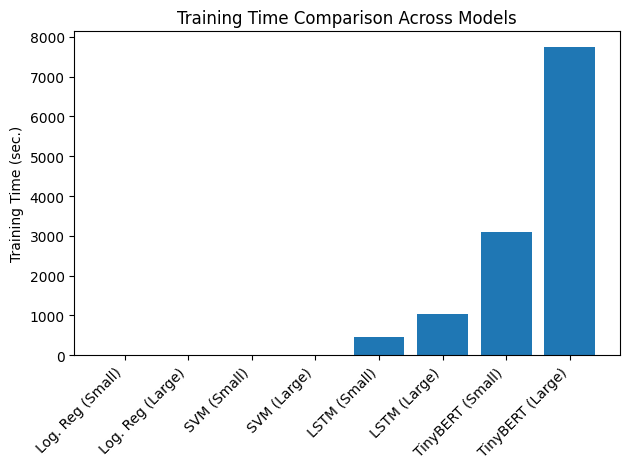

In [49]:

plt.bar(results_df["Model"], results_df["Training Time (s)"])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Training Time (sec.)")
plt.title("Training Time Comparison Across Models")
plt.tight_layout()
plt.show()

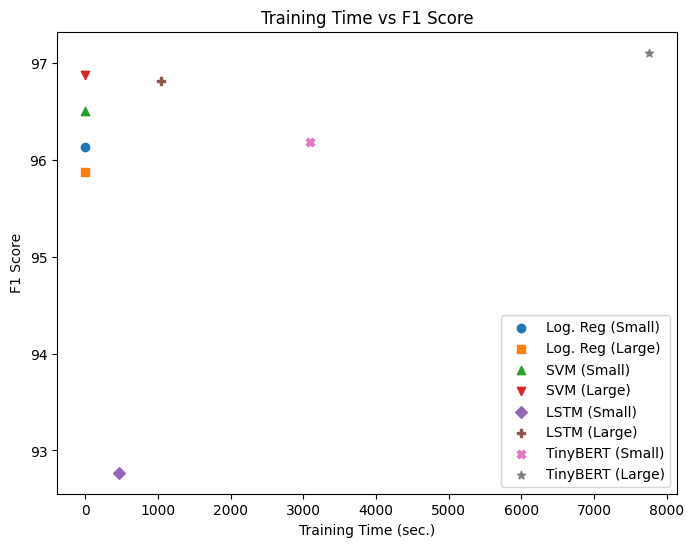

In [47]:
plt.figure(figsize=(8,6))

# plot each point with a different marker & label
plt.scatter(df["Training Time (s)"][0], results_df["F1"][0], marker='o', label="Log. Reg (Small)")
plt.scatter(df["Training Time (s)"][1], results_df["F1"][1], marker='s', label="Log. Reg (Large)")

plt.scatter(df["Training Time (s)"][2], results_df["F1"][2], marker='^', label="SVM (Small)")
plt.scatter(df["Training Time (s)"][3], results_df["F1"][3], marker='v', label="SVM (Large)")

plt.scatter(df["Training Time (s)"][4], results_df["F1"][4], marker='D', label="LSTM (Small)")
plt.scatter(df["Training Time (s)"][5], results_df["F1"][5], marker='P', label="LSTM (Large)")

plt.scatter(df["Training Time (s)"][6], results_df["F1"][6], marker='X', label="TinyBERT (Small)")
plt.scatter(df["Training Time (s)"][7], results_df["F1"][7], marker='*', label="TinyBERT (Large)")

plt.xlabel("Training Time (sec.)")
plt.ylabel("F1 Score")
plt.title("Training Time vs F1 Score")

plt.legend()
plt.show()

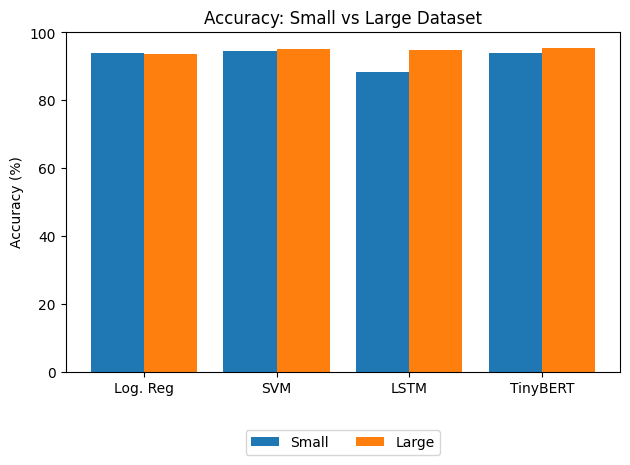

In [55]:
## Used Chat GPT for this one!

small_acc = results_df["Accuracy"][::2]  # every other row = small
large_acc = results_df["Accuracy"][1::2] # large dataset

labels = ["Log. Reg", "SVM", "LSTM", "TinyBERT"]
x = range(len(labels))

plt.bar(x, small_acc, width=0.4, label="Small")
plt.bar([i + 0.4 for i in x], large_acc, width=0.4, label="Large")

plt.xticks([i+0.2 for i in x], labels)
plt.ylabel("Accuracy (%)")
plt.title("Accuracy: Small vs Large Dataset")

plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.tight_layout()
plt.show()